Script Overview
1. Filters docs to go from 2022-2024
2. Checks for docs that have uncertainty 
3. Plots the distribution of uncertainty terms per doc 
4. Plots unique words per doc
5. Plots type of term and frequency
6. Looks at context around uncertainty terms (single words) found
7. Implementation of Bigrams

1. Filters docs to go from 2022-2024

In [1]:
import os
from datetime import datetime
import shutil

def filter_articles_CBS_GEN(directory, output_directory):
    filtered_articles = []

    for file in os.listdir(directory):
        if file.endswith("txt"):
            article_path = os.path.join(directory, file)

            with open(article_path, "r") as f:
                text = f.readlines()

                date = text[1].strip().replace("Date: ", "")

                try:
                    a_date = datetime.strptime(date, "%Y-%m-%d %H:%M:%S %Z")
                    if a_date >= datetime(2022,1,1):
                        filtered_articles.append(article_path)
                        output_path = os.path.join(output_directory, file)
                        shutil.copy(article_path, output_path)

                except ValueError:
                    print(f"Skipping {file} due to incorrect data format")

    return(filtered_articles)

In [2]:
directory = "scraped_articles"
output_directory = "filt_art"
filt_art = filter_articles_CBS_GEN(directory, output_directory)


Skipping error_files.txt due to incorrect data format


In [3]:
len(os.listdir("filt_art"))

1537

2. Checks for docs that have uncertainty 

In [4]:

uncertainty_terms = set([
    "altijd", "kans", "meestal", "misschien", "mogelijk", "nooit", "onmogelijk", "onwaarschijnlijk", "onzeker", 
    "soms", "twijfelachtig", "vaak", "vermoedelijk","waarschijnlijk", "zeker", "zelden", "bijna"
])

def tokenize(doc):
    with open(file_path, "r") as f:
        lines = f.readlines()[4:]
        text = "".join(lines)
    doc = nlp(text)

    return(doc)

def find_uncertainty_terms(doc_tokens):
    found_terms = []
    found_terms += [w.text.lower() for w in doc_tokens if w.text.lower() in uncertainty_terms]
    return found_terms



In [5]:
import os 
import spacy
nlp = spacy.load("nl_core_news_sm")

doc_u_counts = []
filenames = []
total_u_counts = 0
for file in os.listdir("filt_art"):
    file_path = os.path.join("filt_art", file)
    doc = tokenize(file_path)
    terms = find_uncertainty_terms(doc)
    if terms:
        total_u_counts += 1
        doc_u_counts.append(len(terms))
        filenames.append(file)
    

In [6]:
import pandas as pd
df =pd.DataFrame(doc_u_counts , index = filenames , columns = ["Uncertainty Counts"])
# checking max number of terms per doc
df["Uncertainty Counts"].sort_values(ascending= False)

mannen-gaan-na-een-scheiding-vaker-opnieuw-samenwonen-dan-vrouwen.txt             19
bijna-21-miljoen-luchtvaartpassagiers-in-derde-kwartaal-2023.txt                  16
ruim-helft-nederlanders-werkt-weleens-thuis.txt                                   14
meer-ondernemers-verwachten-stijging-verkoopprijzen.txt                           14
bijna-70-procent-van-ouderen-heeft-minstens-elke-week-contact-met-de-buren.txt    13
                                                                                  ..
koopwoningen-in-oktober-11-5-procent-duurder-dan-jaar-eerder.txt                   1
nederlandse-emissie-intensiteit-broeikasgassen-lager-dan-gemiddelde-in-eu.txt      1
meer-koeien-in-de-wei-maar-wel-korter.txt                                          1
steeds-meer-nederlanders-gebruiken-slimme-apparaten.txt                            1
omzetstijging-transportsector-vierde-kwartaal-minder-groot.txt                     1
Name: Uncertainty Counts, Length: 1047, dtype: int64

In [8]:
# sorting docs into number of uncertainty words they contain
counts = df["Uncertainty Counts"].value_counts()
counts.sort_index()

Uncertainty Counts
1     339
2     223
3     170
4     116
5      69
6      50
7      32
8      14
9      15
10      6
11      6
12      2
13      1
14      2
16      1
19      1
Name: count, dtype: int64

3. Plots the distribution of uncertainty terms per doc 

Text(5.069444444444445, 0.5, 'Number of documents')

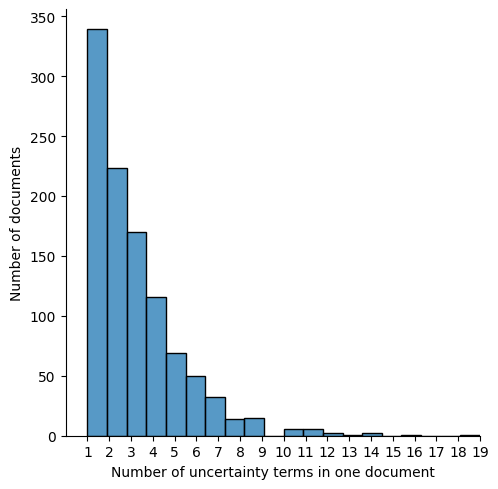

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.displot(df["Uncertainty Counts"], bins = 20)
plt.xlim(0,19)
plt.xticks(ticks=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])


plt.xlabel("Number of uncertainty terms in one document")
plt.ylabel("Number of documents")


Text(0, 0.5, 'Number of documents')

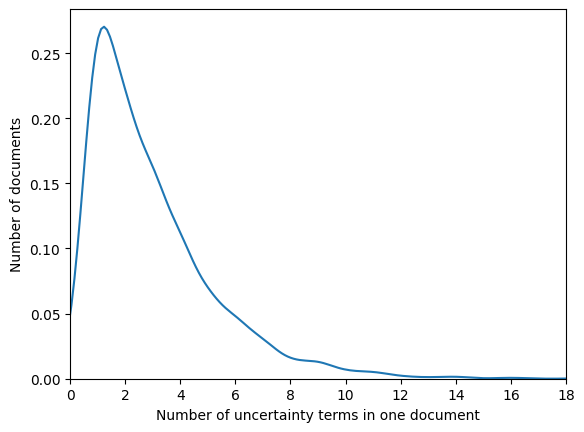

In [24]:
sns.kdeplot(df["Uncertainty Counts"], common_norm= False)
plt.xlim(0,18)
plt.xlabel("Number of uncertainty terms in one document")
plt.ylabel("Number of documents")

(0.0, 18.0)

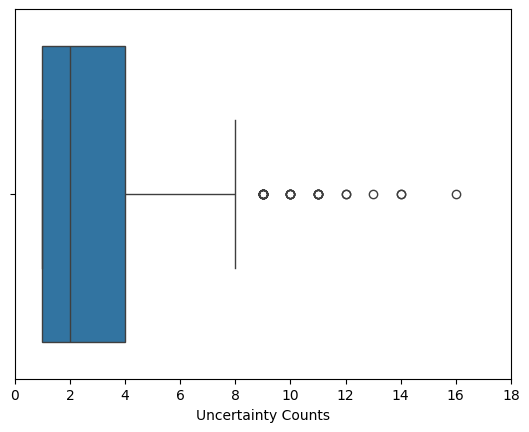

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x = df["Uncertainty Counts"])
plt.xlim(0,18)

4. Plots unique words per doc

In [2]:
import os
import pandas as pd
import os 
import spacy
nlp = spacy.load("nl_core_news_sm")

uncertainty_terms = set([
    "altijd", "kans", "meestal", "misschien", "mogelijk", "nooit", "onmogelijk", "onwaarschijnlijk", "onzeker", 
    "soms", "twijfelachtig", "vaak", "vermoedelijk","waarschijnlijk", "zeker", "zelden", "bijna"
])


def tokenize(file):
    with open(file, "r") as f:
        lines = f.readlines()[4:]
        text = "".join(lines)
    doc = nlp(text)
    return doc
    


def find_uncertainty_term(doc_tok):
    found_terms = set()
    found_terms.update([w.text.lower() for w in doc if w.text.lower() in uncertainty_terms])
    return found_terms


    
doc_u_counts = []
filenames = []
unique_terms = []
total_uc = 0
for file in os.listdir("filt_art"):
    filepath = os.path.join("filt_art", file)
    doc = tokenize(filepath)
    found_terms = find_uncertainty_term(doc)

    if found_terms:
        total_uc += 1

        doc_u_counts.append(len(found_terms))
        filenames.append(file)
        unique_terms.append(found_terms)


df = pd.DataFrame(doc_u_counts, index = filenames, columns = ["Unique Uncertainty Terms"] )


In [ ]:
# sorting unique counts per document
counts = df["Unique Uncertainty Terms"].value_counts().sort_index()
counts_sorted = counts.sort_index(ascending = False)
counts_sorted

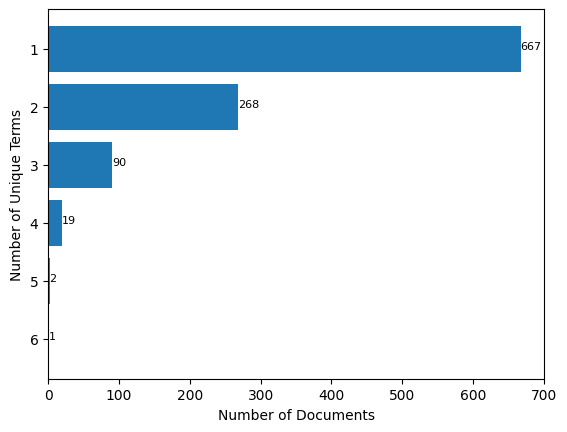

In [5]:
import matplotlib.pyplot as plt
plt.figure()
plt.barh(y = range(len(counts_sorted.index)), width = counts_sorted.values)
plt.yticks(ticks=range(len(counts_sorted)), labels = counts_sorted.index)
for idx, value in enumerate(counts_sorted.values):
    plt.text(value, idx, f"{value}", fontsize = 8)
plt.ylabel("Number of Unique Terms")
plt.xlabel("Number of Documents")
plt.savefig("statcan_unique_dist.png")
plt.show("Unique Term Uncertainty Count")

5. Plots type of term and frequency

In [8]:
# for this we will use Counter
import os
import pandas as pd
import spacy
from collections import Counter 
nlp = spacy.load("nl_core_news_sm")


uncertainty_terms = set([
    "altijd", "kans", "meestal", "misschien", "mogelijk", "nooit", "onmogelijk", "onwaarschijnlijk", "onzeker", 
    "soms", "twijfelachtig", "vaak", "vermoedelijk","waarschijnlijk", "zeker", "zelden", "bijna"
])

def tokenize(file):
    with open(file, "r") as f:
        lines = f.readlines()[4:]
        text = "".join(lines)
    doc = nlp(text)

    return(doc)

def find_uncertainty_terms(doc_tokens):
    found_terms = []
    found_terms += [w.text.lower() for w in doc_tokens if w.text.lower() in uncertainty_terms]
    return found_terms
    
doc_u_counts = Counter()
found_terms = []

for file in os.listdir("filt_art"):
    filepath = os.path.join("filt_art", file)
    doc = tokenize(filepath)
    terms = find_uncertainty_terms(doc)
    doc_u_counts.update(terms)
    

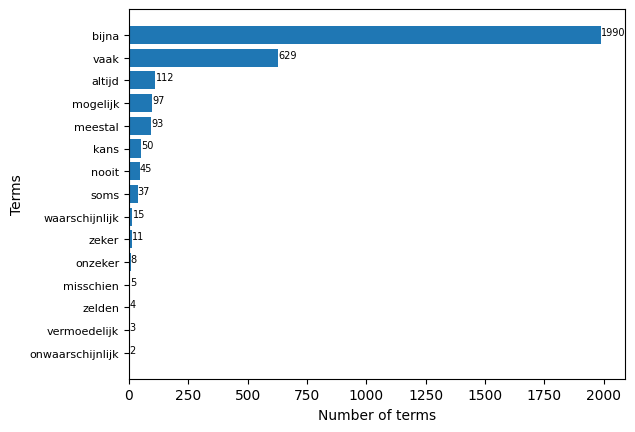

In [12]:
import matplotlib.pyplot as plt
y = list(doc_u_counts.values())
x = list(doc_u_counts.keys())

import matplotlib.pyplot as plt
def addlabels(df_sorted):
    for i in range(len(df_sorted)):
        plt.text(df_sorted.iloc[i]["freq"] + 0.2,i, str(df_sorted.iloc[i]["freq"]), fontsize = 7)


df_sorted = df_sorted.sort_values(by = "freq", ascending=True)
plt.barh(df_sorted["words"] ,df_sorted["freq"])
addlabels(df_sorted)
plt.xlabel("Number of terms")
plt.ylabel("Terms")
plt.yticks(fontsize = 8)
plt.show()

6. Looks at context around uncertainty terms (single words) found

In [ ]:
import os
import spacy
from nltk.util import ngrams


nlp = spacy.load("nl_core_news_sm")

uncertainty_terms = set([
    "altijd", "kans", "meestal", "misschien", "mogelijk", "nooit", "onmogelijk", "onwaarschijnlijk", "onzeker", 
    "soms", "twijfelachtig", "vaak", "vermoedelijk","waarschijnlijk", "zeker", "zelden", "bijna"
])


# tokenization fnc
excluded_tokens = set()
def tokenize_text(file_path):
    with open(file_path, "r") as f:
        text = f.read()

    doc = nlp(text)
    return doc

# uncertainty fnc
def find_uncertainty_terms(doc_tokens):
    found_terms = []
    found_terms += [word.text.lower() for word in doc_tokens if word.text.lower() in uncertainty_terms]
    return found_terms

# term context fnc
def find_word_context(doc_tokens, word, window=10):
    term_contexts = []
    
    for i, token in enumerate(doc_tokens):
        if token.text.lower() == word.lower():
            start = max(0, i - window)
            end = min(len(doc_tokens), i + window + 1)
            term_contexts.append(doc_tokens[start:end])

    return term_contexts

# Directory with files
directory = "filt_art"  

# Directory where files with word context will be done
output_directory = "term_contexts"

output_file_path = os.path.join(output_directory, "bijna.txt")


with open(output_file_path, "w") as out_file:
    for file in os.listdir(directory):
        file_path = os.path.join(directory, file)
        doc = tokenize_text(file_path)

        
        word_contexts = find_word_context(doc, "bijna")
        
        if word_contexts:
            out_file.write(f"Title : {file}\n")

            for ctx in word_contexts:
                out_file.write("Context:" + " ".join([token.text for token in ctx]) + "\n")
            out_file.write("\n")


7. Implementation of Bigrams

In [7]:
import spacy 
from spacy.matcher import PhraseMatcher

In [8]:
import os

nlp = spacy.load("nl_core_news_sm")

# create bigrams -> turn into docs so phrase matcher can work with it 
matcher = PhraseMatcher(nlp.vocab)

bigrams = ["bijna altijd", "bijna nooit","bijna onmogelijk", "bijna zeker", "heel vaak", 
            "kan gebeuren", "kleine kans", "te verwachten", "zeer onwaarschijnlijk", "zeer waarschijnlijk", "flink minder",
            "minder vaak", "flink gedaald"]

patterns = [nlp(bigram) for bigram in bigrams]

matcher.add("BIGRAMS", patterns)

def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[5:]
        text = "".join(lines)
    doc = nlp(text)
    return doc

for file in os.listdir("filt_art"):
    file_path = os.path.join("filt_art", file)
    doc = tokenize_text(file_path)
    matches = matcher(doc)   

    for match_id, start, end in matches:
        matched_span = doc[start:end]
        print(f"Matched bigram: '{matched_span.text}' in file {file}")


Matched bigram: 'minder vaak' in file meeste-jongeren-kiezen-opleiding-die-hen-het-leukst-lijkt.txt
Matched bigram: 'te verwachten' in file omzet-industrie-in-eerste-kwartaal-24-5-procent-hoger.txt
Matched bigram: 'minder vaak' in file meisjes-in-2020-21-opnieuw-lager-schooladvies.txt
Matched bigram: 'kan gebeuren' in file verkenning-bevolking-2050-meer-ouderen-en-meer-hoogopgeleiden.txt
Matched bigram: 'minder vaak' in file meer-stakingen-in-2021.txt
Matched bigram: 'minder vaak' in file meer-stakingen-in-2021.txt
Matched bigram: 'minder vaak' in file vier-keer-zoveel-mannen-als-vrouwen-onder-jonge-technici.txt
Matched bigram: 'zeer onwaarschijnlijk' in file consumentenvertrouwen-bereikt-nieuw-dieptepunt.txt
Matched bigram: 'minder vaak' in file zorgen-over-financiele-toekomst-in-jaar-tijd-flink-toegenomen.txt
Matched bigram: 'minder vaak' in file zorgen-over-financiele-toekomst-in-jaar-tijd-flink-toegenomen.txt
Matched bigram: 'minder vaak' in file bijna-1-op-de-5-jongeren-slachtoffe

In [9]:
import os

nlp = spacy.load("nl_core_news_sm")
from collections import Counter

# create bigrams -> turn into docs so phrase matcher can work with it 
matcher = PhraseMatcher(nlp.vocab)

bigrams = ["bijna altijd", "bijna nooit","bijna onmogelijk", "bijna zeker", "heel vaak", 
            "kan gebeuren", "kleine kans", "te verwachten", "zeer onwaarschijnlijk", "zeer waarshcijnlijk", "flink minder",
            "minder vaak", "flink gedaald"]

patterns = [nlp(bigram) for bigram in bigrams]

matcher.add("BIGRAMS", patterns)

def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[5:]
        text = "".join(lines)
    doc = nlp(text)
    return doc

bigram_count = Counter()
for file in os.listdir("filt_art"):
    file_path = os.path.join("filt_art", file)
    doc = tokenize_text(file_path)
    matches = matcher(doc)   

    for match_id, start, end in matches:
        matched_span = doc[start:end]
        bigram_count[matched_span.text] += 1

b_counts = bigram_count.most_common()
      



Text(0, 0.5, 'Terms')

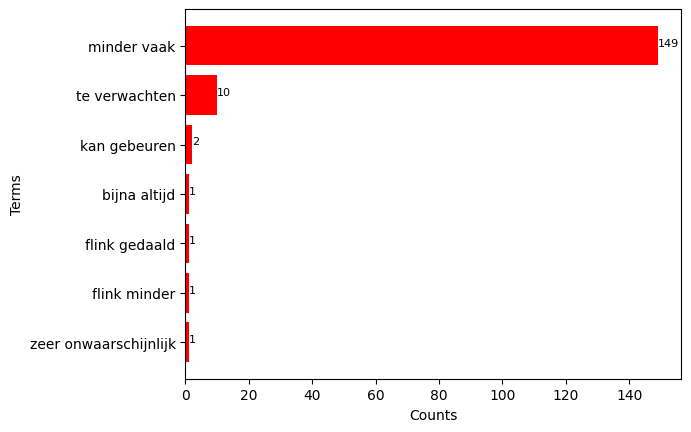

In [12]:
b_counts.sort(key = lambda x:x[1], reverse = False)  
bigrams , counts = zip(*b_counts)
plt.figure()
bars = plt.barh(bigrams, counts, color = "red")
for bar in bars:
    x_value = bar.get_width()
    plt.text(x_value, bar.get_y() + bar.get_height()/2 , str(x_value), fontsize = 8)

plt.xlabel("Counts")
plt.ylabel("Terms")
